In [ ]:
!unzip "/content/drive/MyDrive/Internship Projects/Food_Classification/food data.zip" -d "/content/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/food data/train/kadai_paneer/337.jpg  
  inflating: /content/food data/train/kadai_paneer/338.jpg  
   creating: /content/food data/train/Kulfi/
  inflating: /content/food data/train/Kulfi/001.jpg  
  inflating: /content/food data/train/Kulfi/002.jpg  
  inflating: /content/food data/train/Kulfi/003.jpg  
  inflating: /content/food data/train/Kulfi/004.jpg  
  inflating: /content/food data/train/Kulfi/005.jpg  
  inflating: /content/food data/train/Kulfi/006.jpg  
  inflating: /content/food data/train/Kulfi/007.cms  
  inflating: /content/food data/train/Kulfi/007.jpg  
  inflating: /content/food data/train/Kulfi/008.jpg  
  inflating: /content/food data/train/Kulfi/009.jpg  
  inflating: /content/food data/train/Kulfi/010.jpg  
  inflating: /content/food data/train/Kulfi/011.jpg  
  inflating: /content/food data/train/Kulfi/012.jpg  
  inflating: /content/food data/train/Kulfi/013.jpg  
  inflating: /content/food

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

In [ ]:
os.listdir("/content/food data")

['valid', 'test', 'train']

In [ ]:
os.listdir("/content/food data/train")

['dhokla',
 'burger',
 'Crispy Chicken',
 'dal_makhani',
 'chole_bhature',
 'Taco',
 'paani_puri',
 'pav_bhaji',
 'Fries',
 'omelette',
 'Baked Potato',
 'Hot Dog',
 'fried_rice',
 'chapati',
 'idli',
 'Kulfi',
 'pizza',
 'cheesecake',
 'jalebi',
 'kadai_paneer',
 'apple_pie',
 'ice_cream',
 'chai',
 'momos',
 'Donut',
 'Pakode',
 'Sandwich',
 'sushi',
 'chicken_curry',
 'Taquito',
 'butter_naan',
 'kaathi_rolls',
 'Masala dosa',
 'samosa']

In [ ]:
os.listdir("/content/food data/valid")

['dhokla',
 'kulfi',
 'burger',
 'pakode',
 'Crispy Chicken',
 'dal_makhani',
 'chole_bhature',
 'Taco',
 'paani_puri',
 'pav_bhaji',
 'Fries',
 'omelette',
 'Baked Potato',
 'Hot Dog',
 'fried_rice',
 'chapati',
 'idli',
 'pizza',
 'cheesecake',
 'jalebi',
 'kadai_paneer',
 'apple_pie',
 'ice_cream',
 'masala_dosa',
 'chai',
 'momos',
 'Donut',
 'Sandwich',
 'sushi',
 'chicken_curry',
 'Taquito',
 'butter_naan',
 'kaathi_rolls',
 'samosa']

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
train_data_path = "/content/food data/train"
valid_data_path = "/content/food data/valid"

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
label_names = ['Baked Potato',
 'Pakode',
 'chapati',
 'chicken_curry',
 'Kulfi',
 'Taco',
 'burger',
 'momos',
 'Donut',
 'butter_naan',
 'Masala dosa',
 'Fries',
 'dal_makhani',
 'jalebi',
 'chole_bhature',
 'pav_bhaji',
 'pizza',
 'samosa',
 'kaathi_rolls',
 'fried_rice',
 'ice_cream',
 'dhokla',
 'Crispy Chicken',
 'Sandwich',
 'chai',
 'sushi',
 'idli',
 'apple_pie',
 'kadai_paneer',
 'Hot Dog',
 'cheesecake',
 'Taquito',
 'omelette',
 'paani_puri']

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# To Train the CNN well we are going to use Data Augumentation

train_data_rules = ImageDataGenerator(rescale = 1 / 255.0 ,
                                      rotation_range = 0.2 ,
                                      shear_range=0.2 ,
                                      horizontal_flip = True)

val_data_rules = ImageDataGenerator(rescale = 1 / 255.0 ,
                                      rotation_range = 0.2 ,
                                      shear_range=0.2 ,
                                      horizontal_flip = True)

In [ ]:
final_train_data = train_data_rules.flow_from_directory(train_data_path , target_size=(256,256) ,
                                     color_mode='rgb',
                                     classes=label_names , class_mode='categorical')

final_val_data = val_data_rules.flow_from_directory(valid_data_path , target_size=(256,256) ,
                                     color_mode='rgb',
                                     classes=label_names , class_mode='categorical')



Found 8499 images belonging to 34 classes.
Found 1550 images belonging to 34 classes.


**Binary Custom Architecure**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Flatten
from tensorflow.keras.activations import relu,sigmoid

model = Sequential()

# Hiddel Layer_1
model.add(Conv2D(12 , kernel_size=(3,3) ,
                 kernel_initializer = 'he_uniform' ,activation = 'relu'
                 ))

model.add(MaxPooling2D(pool_size=(2,2)))


# Hiddel Layer_2
model.add(Conv2D(6 , kernel_size=(3,3) ,
                 kernel_initializer = 'he_uniform' ,activation = 'relu'
                 ))

model.add(MaxPooling2D(pool_size=(2,2)))

# Hiddel Layer_3
model.add(Conv2D(3 , kernel_size=(3,3) ,
                 kernel_initializer = 'he_uniform' ,activation = 'relu'
                 ))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

# ANN
model.add(Dense(units = 8,kernel_initializer="he_uniform",activation="relu"))
model.add(Dense(units = 4,kernel_initializer="he_uniform",activation="relu"))
model.add(Dense(units = 3,kernel_initializer="he_uniform",activation="relu"))

model.add(Dense(units = 34,kernel_initializer="glorot_uniform",activation="softmax"))



In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['Accuracy'])

In [ ]:
final_train_data.classes

array([ 0,  0,  0, ..., 33, 33, 33], dtype=int32)

In [ ]:
final_train_data.class_indices

{'Baked Potato': 0,
 'Pakode': 1,
 'chapati': 2,
 'chicken_curry': 3,
 'Kulfi': 4,
 'Taco': 5,
 'burger': 6,
 'momos': 7,
 'Donut': 8,
 'butter_naan': 9,
 'Masala dosa': 10,
 'Fries': 11,
 'dal_makhani': 12,
 'jalebi': 13,
 'chole_bhature': 14,
 'pav_bhaji': 15,
 'pizza': 16,
 'samosa': 17,
 'kaathi_rolls': 18,
 'fried_rice': 19,
 'ice_cream': 20,
 'dhokla': 21,
 'Crispy Chicken': 22,
 'Sandwich': 23,
 'chai': 24,
 'sushi': 25,
 'idli': 26,
 'apple_pie': 27,
 'kadai_paneer': 28,
 'Hot Dog': 29,
 'cheesecake': 30,
 'Taquito': 31,
 'omelette': 32,
 'paani_puri': 33}

In [ ]:
model.fit(final_train_data , validation_data=final_val_data , batch_size = 32 , epochs=25)

Epoch 1/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 253s 921ms/step - Accuracy: 0.0235 - loss: 3.5275 - val_Accuracy: 0.0168 - val_loss: 3.5265
Epoch 2/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 215s 808ms/step - Accuracy: 0.0267 - loss: 3.5266 - val_Accuracy: 0.0277 - val_loss: 3.5253
Epoch 3/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 213s 799ms/step - Accuracy: 0.0334 - loss: 3.5188 - val_Accuracy: 0.0439 - val_loss: 3.4970
Epoch 4/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 215s 810ms/step - Accuracy: 0.0453 - loss: 3.4348 - val_Accuracy: 0.0561 - val_loss: 3.4390
Epoch 5/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 216s 810ms/step - Accuracy: 0.0560 - loss: 3.3244 - val_Accuracy: 0.0568 - val_loss: 3.3589
Epoch 6/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 218s 820ms/step - Accuracy: 0.0606 - loss: 3.2476 - val_Accuracy: 0.0606 - val_loss: 3.3425
Epoch 7/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 218s 820ms/step - Accuracy: 0.0611 - loss: 3.2065 - val_Accuracy: 0.0613 - val_loss: 3.3282
Epoch 8/25
266/266 ━━━━━━━━━━━━━━━━━━━━ 218s 820ms/step - Accuracy: 0.0651 -

In [ ]:
model.save_weights("cnn.weights.h5")

In [ ]:
import cv2

In [ ]:
def testing_function(image_path):
  t_image = cv2.imread(image_path,1)
  print(f"Original_image size : {t_image.shape}")
  resized_image = cv2.resize(t_image , (256,256))
  print(f"Resized Image size : {resized_image.shape}")
  scaled_down_image = resized_image / 255.0
  print(f"After Scaling : {scaled_down_image.shape}")
  added_dim_image = np.expand_dims(scaled_down_image , axis=0)
  print(f"After Adding 1 Dim size : {added_dim_image.shape}")
  print(label_names[np.argmax(model.predict(added_dim_image))])

  plt.imshow(t_image[: , : ,::])
  plt.show()

Original_image size : (179, 282, 3)
Resized Image size : (256, 256, 3)
After Scaling : (256, 256, 3)
After Adding 1 Dim size : (1, 256, 256, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
chapati


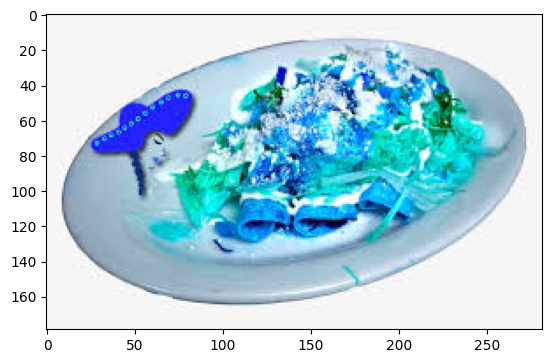

In [ ]:
testing_function("/content/food data/test/Taquito/Taquito-Train (95).jpeg")

In [ ]:
y_true = final_val_data.classes

In [ ]:
y_pred_prob = model.predict(final_val_data)
y_pred = np.argmax(y_pred_prob, axis=1)

49/49 ━━━━━━━━━━━━━━━━━━━━ 34s 679ms/step


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score)

In [ ]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.03225806451612903
Precision: 0.002070640513888093
Recall   : 0.03225806451612903
F1 Score : 0.0038018139807242542


In [ ]:
class_names = list(final_val_data.class_indices.keys())

report = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(class_names))),
    target_names=class_names,
    zero_division=0
)

print(report)

                precision    recall  f1-score   support

  Baked Potato       0.00      0.00      0.00        50
        Pakode       0.00      0.00      0.00         0
       chapati       0.04      0.82      0.07        50
 chicken_curry       0.00      0.00      0.00        50
         Kulfi       0.00      0.00      0.00         0
          Taco       0.00      0.00      0.00        50
        burger       0.00      0.00      0.00        50
         momos       0.00      0.00      0.00        50
         Donut       0.00      0.00      0.00        50
   butter_naan       0.00      0.00      0.00        50
   Masala dosa       0.00      0.00      0.00         0
         Fries       0.00      0.00      0.00        50
   dal_makhani       0.00      0.00      0.00        50
        jalebi       0.00      0.00      0.00        50
 chole_bhature       0.00      0.00      0.00        50
     pav_bhaji       0.00      0.00      0.00        50
         pizza       0.00      0.00      0.00  

In [ ]:
import json
from sklearn.metrics import classification_report

class_names = list(final_val_data.class_indices.keys())

report = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(class_names))),
    target_names=class_names,
    zero_division=0,
    output_dict=True
)

with open("classification_report_CNN.json", "w") as f:
    json.dump(report, f, indent=4)

In [ ]:
model.save("cnn.keras")